In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/LICENSE.txt
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/CC-BY-4.0.txt
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_30_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_17_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_44_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_31_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_40_EX.tif
/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation/2. All Segme

Number of training images: 54
Number of existing MA masks: 54
Number of existing HE masks: 53
Number of existing EX masks: 54
Number of existing SE masks: 26

Missing mask counts:
MA: 0
HE: 1
EX: 0
SE: 28

Missing masks will be replaced with all-zero masks.

Visualizing sample IDs: ['IDRiD_01', 'IDRiD_02', 'IDRiD_03']

Verification for: IDRiD_01
Original image shape: (2848, 4288, 3)
Resized image shape: (512, 512, 3)
CLAHE image shape: (512, 512, 3)
Normalized image shape: (512, 512, 3)
MA status: Found
Resized MA mask shape: (512, 512)
HE status: Found
Resized HE mask shape: (512, 512)
EX status: Found
Resized EX mask shape: (512, 512)
SE status: Missing - zero mask created
Resized SE mask shape: (512, 512)


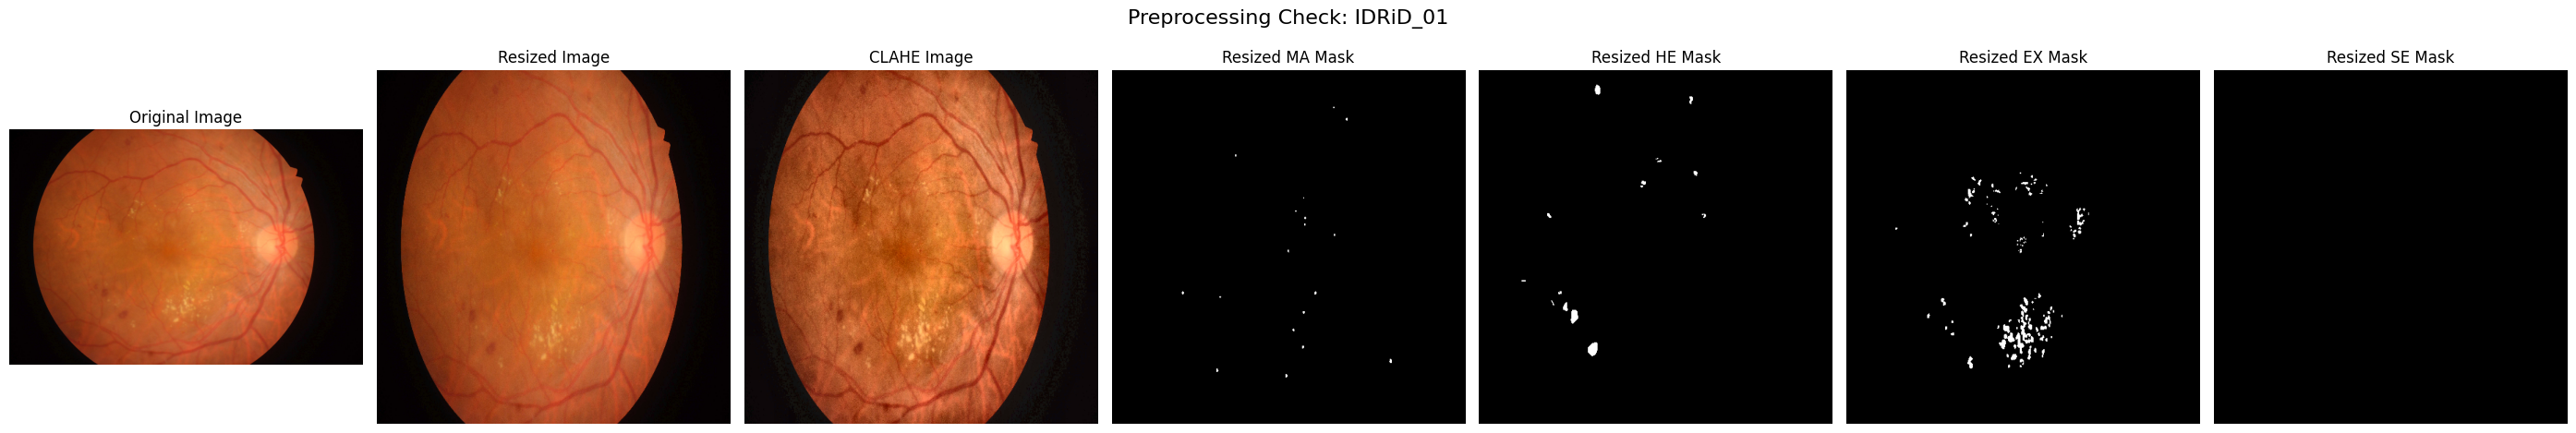


Verification for: IDRiD_02
Original image shape: (2848, 4288, 3)
Resized image shape: (512, 512, 3)
CLAHE image shape: (512, 512, 3)
Normalized image shape: (512, 512, 3)
MA status: Found
Resized MA mask shape: (512, 512)
HE status: Found
Resized HE mask shape: (512, 512)
EX status: Found
Resized EX mask shape: (512, 512)
SE status: Missing - zero mask created
Resized SE mask shape: (512, 512)


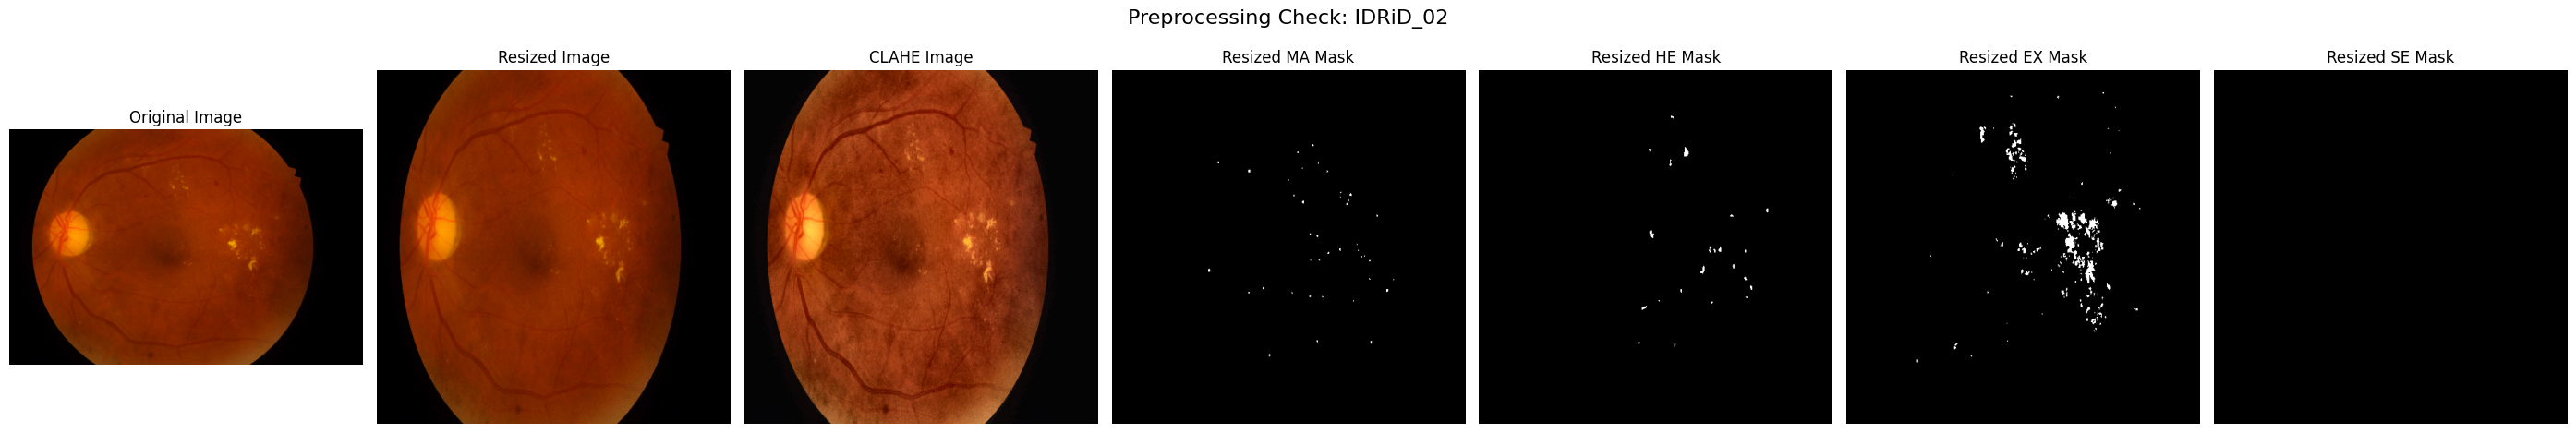


Verification for: IDRiD_03
Original image shape: (2848, 4288, 3)
Resized image shape: (512, 512, 3)
CLAHE image shape: (512, 512, 3)
Normalized image shape: (512, 512, 3)
MA status: Found
Resized MA mask shape: (512, 512)
HE status: Found
Resized HE mask shape: (512, 512)
EX status: Found
Resized EX mask shape: (512, 512)
SE status: Found
Resized SE mask shape: (512, 512)


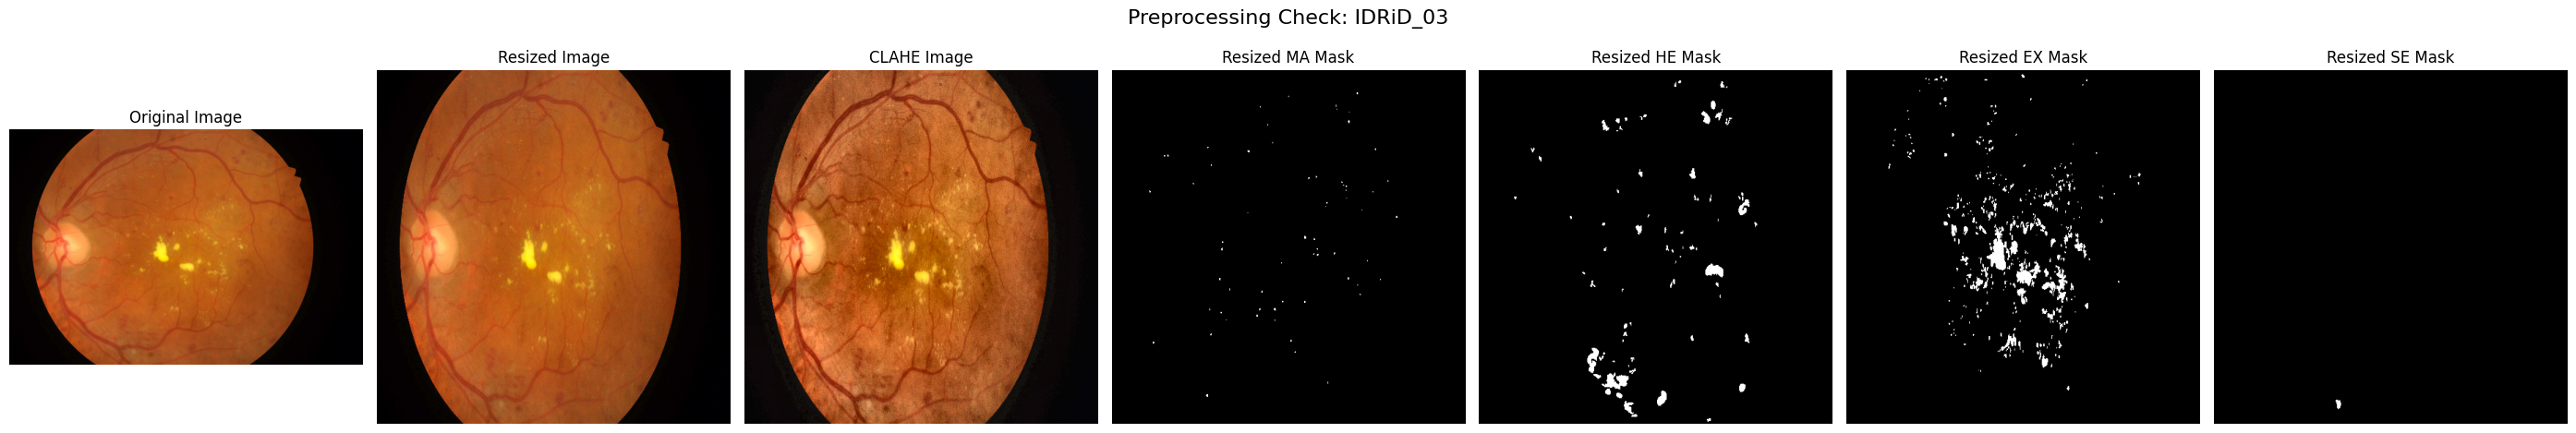

In [2]:
import glob
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# Paths
# =========================

BASE = Path("/kaggle/input/datasets/studentkrithika/idrid-dataset/A. Segmentation")

IMG_TRAIN_DIR = BASE / "1. Original Images" / "a. Training Set"
GT_TRAIN_DIR = BASE / "2. All Segmentation Groundtruths" / "a. Training Set"

MASK_DIRS = {
    "MA": GT_TRAIN_DIR / "1. Microaneurysms",
    "HE": GT_TRAIN_DIR / "2. Haemorrhages",
    "EX": GT_TRAIN_DIR / "3. Hard Exudates",
    "SE": GT_TRAIN_DIR / "4. Soft Exudates",
}

TARGET_SIZE = (512, 512)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


# =========================
# Helper functions
# =========================

def list_files(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]
    files = []

    for ext in exts:
        files.extend(glob.glob(str(folder / ext)))

    return sorted(files)


def get_image_id(path):
    stem = Path(path).stem
    parts = stem.split("_")

    if len(parts) >= 2:
        return parts[0] + "_" + parts[1]

    return stem


def make_id_map(files):
    return {get_image_id(file): file for file in files}


def load_rgb_image(path):
    image = Image.open(path).convert("RGB")
    return np.array(image)


def load_mask(path):
    mask = Image.open(path).convert("L")
    return np.array(mask)


def create_zero_mask(image):
    """
    Create an all-zero mask with the same height and width
    as the original RGB image.
    """
    height, width = image.shape[:2]
    return np.zeros((height, width), dtype=np.uint8)


def resize_rgb_image(image):
    return cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)


def resize_mask(mask):
    return cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)


def apply_clahe_rgb(image):
    """
    Apply CLAHE only to the RGB image.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced_l = clahe.apply(l_channel)
    enhanced_lab = cv2.merge((enhanced_l, a_channel, b_channel))
    enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

    return enhanced_rgb


def imagenet_normalize(image):
    """
    Apply ImageNet normalization only to the image.
    """
    image = image.astype(np.float32) / 255.0
    normalized = (image - IMAGENET_MEAN) / IMAGENET_STD

    return normalized


def prepare_sample(image_id, image_map, mask_maps):
    """
    Load one image and its MA, HE, EX, SE masks.

    If a lesion mask is missing, create an all-zero mask
    with the same size as the original image.
    """

    # Original image must exist
    assert image_id in image_map, f"Original image missing for {image_id}"

    image_path = image_map[image_id]
    original_image = load_rgb_image(image_path)

    masks = {}
    mask_status = {}

    for mask_name in ["MA", "HE", "EX", "SE"]:

        if image_id in mask_maps[mask_name]:
            mask_path = mask_maps[mask_name][image_id]
            masks[mask_name] = load_mask(mask_path)
            mask_status[mask_name] = "Found"

        else:
            masks[mask_name] = create_zero_mask(original_image)
            mask_status[mask_name] = "Missing - zero mask created"

    # Resize image and masks
    resized_image = resize_rgb_image(original_image)

    resized_masks = {
        mask_name: resize_mask(mask)
        for mask_name, mask in masks.items()
    }

    # Apply CLAHE only to RGB image
    clahe_image = apply_clahe_rgb(resized_image)

    # Apply ImageNet normalization only to image
    normalized_image = imagenet_normalize(clahe_image)

    # =========================
    # Verification checks
    # =========================

    assert resized_image.shape == (512, 512, 3), f"Wrong resized image shape: {resized_image.shape}"
    assert clahe_image.shape == (512, 512, 3), f"Wrong CLAHE image shape: {clahe_image.shape}"
    assert normalized_image.shape == (512, 512, 3), f"Wrong normalized image shape: {normalized_image.shape}"

    for mask_name, mask in resized_masks.items():
        assert mask.shape == (512, 512), f"Wrong {mask_name} mask shape: {mask.shape}"
        assert mask.dtype == np.uint8, f"{mask_name} mask should be uint8"

    assert resized_image.dtype == np.uint8
    assert clahe_image.dtype == np.uint8
    assert normalized_image.dtype in [np.float32, np.float64]

    return {
        "image_id": image_id,
        "original_image": original_image,
        "resized_image": resized_image,
        "clahe_image": clahe_image,
        "normalized_image": normalized_image,
        "resized_masks": resized_masks,
        "mask_status": mask_status,
    }


def visualize_sample(sample):
    image_id = sample["image_id"]
    masks = sample["resized_masks"]

    fig, axes = plt.subplots(1, 7, figsize=(28, 5))

    axes[0].imshow(sample["original_image"])
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(sample["resized_image"])
    axes[1].set_title("Resized Image")
    axes[1].axis("off")

    axes[2].imshow(sample["clahe_image"])
    axes[2].set_title("CLAHE Image")
    axes[2].axis("off")

    for ax, mask_name in zip(axes[3:], ["MA", "HE", "EX", "SE"]):
        ax.imshow(masks[mask_name], cmap="gray")
        ax.set_title(f"Resized {mask_name} Mask")
        ax.axis("off")

    plt.suptitle(f"Preprocessing Check: {image_id}", fontsize=16)
    plt.tight_layout()
    plt.show()


# =========================
# Build maps
# =========================

image_files = list_files(IMG_TRAIN_DIR)
image_map = make_id_map(image_files)

mask_maps = {}

for mask_name, mask_dir in MASK_DIRS.items():
    mask_files = list_files(mask_dir)
    mask_maps[mask_name] = make_id_map(mask_files)

print("Number of training images:", len(image_map))

for mask_name in ["MA", "HE", "EX", "SE"]:
    print(f"Number of existing {mask_name} masks:", len(mask_maps[mask_name]))


# =========================
# Verify missing masks are handled
# =========================

image_ids = sorted(image_map.keys())

missing_counts = {
    "MA": 0,
    "HE": 0,
    "EX": 0,
    "SE": 0,
}

for image_id in image_ids:
    for mask_name in ["MA", "HE", "EX", "SE"]:
        if image_id not in mask_maps[mask_name]:
            missing_counts[mask_name] += 1

print("\nMissing mask counts:")
for mask_name, count in missing_counts.items():
    print(f"{mask_name}: {count}")

print("\nMissing masks will be replaced with all-zero masks.")


# =========================
# Visualize 3 samples
# =========================

sample_ids = image_ids[:3]

print("\nVisualizing sample IDs:", sample_ids)

for image_id in sample_ids:
    sample = prepare_sample(image_id, image_map, mask_maps)

    print("\nVerification for:", image_id)
    print("Original image shape:", sample["original_image"].shape)
    print("Resized image shape:", sample["resized_image"].shape)
    print("CLAHE image shape:", sample["clahe_image"].shape)
    print("Normalized image shape:", sample["normalized_image"].shape)

    for mask_name in ["MA", "HE", "EX", "SE"]:
        print(f"{mask_name} status:", sample["mask_status"][mask_name])
        print(f"Resized {mask_name} mask shape:", sample["resized_masks"][mask_name].shape)

    visualize_sample(sample)